In [1]:
import os
import requests
from dotenv import load_dotenv
import pandas as pd

In [2]:
load_dotenv()

api_key = os.getenv("FRED_API_KEY")

url = "https://api.stlouisfed.org/fred/series/observations"
cpi_yoy = 'CORESTICKM159SFRBATL'
params = {
    "series_id": cpi_yoy,
    "api_key": api_key,
    "file_type": "json"
}

response = requests.get(url, params=params)


In [3]:
response

<Response [200]>

In [4]:
# 200 means its good

In [5]:
# Extract observations and create the table
data = response.json()
data.keys()

dict_keys(['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations'])

In [6]:
data

{'realtime_start': '2026-09-11',
 'realtime_end': '2026-09-11',
 'observation_start': '1600-01-01',
 'observation_end': '9999-12-31',
 'units': 'lin',
 'output_type': 1,
 'file_type': 'json',
 'order_by': 'observation_date',
 'sort_order': 'asc',
 'count': 705,
 'offset': 0,
 'limit': 100000,
 'observations': [{'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1967-12-01',
   'value': '.'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-01-01',
   'value': '3.65186106'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-02-01',
   'value': '3.673819411'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-03-01',
   'value': '4.142163975'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-04-01',
   'value': '4.155828095'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-05-01',
   

In [7]:
cpi_table = pd.DataFrame(data["observations"])

In [8]:
cpi_table.head()

,realtime_start,realtime_end,date,value
0,2026-09-11,2026-09-11,1967-12-01,.
1,2026-09-11,2026-09-11,1968-01-01,3.65186106
2,2026-09-11,2026-09-11,1968-02-01,3.673819411
3,2026-09-11,2026-09-11,1968-03-01,4.142163975
4,2026-09-11,2026-09-11,1968-04-01,4.155828095


In [9]:
cpi_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   realtime_start  705 non-null    str  
 1   realtime_end    705 non-null    str  
 2   date            705 non-null    str  
 3   value           705 non-null    str  
dtypes: str(4)
memory usage: 22.2 KB


In [10]:
# this shows that there are no null values, but I was able to see in my df that the first df['value'] was "."
# I will convert everything to the right dtype and try again. 

In [11]:
# Drop first row because value is "."
cpi_table = cpi_table.drop(cpi_table.index[0])

# Convert columns
cpi_table["realtime_start"] = pd.to_datetime(cpi_table["realtime_start"])
cpi_table["realtime_end"] = pd.to_datetime(cpi_table["realtime_end"])
cpi_table["date"] = pd.to_datetime(cpi_table["date"])
cpi_table["value"] = pd.to_numeric(cpi_table["value"])

In [12]:
cpi_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 1 to 704
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   realtime_start  704 non-null    datetime64[us]
 1   realtime_end    704 non-null    datetime64[us]
 2   date            704 non-null    datetime64[us]
 3   value           704 non-null    float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 22.1 KB


In [13]:
# ok looks like there is no null data

In [14]:
cpi_table.describe()

,realtime_start,realtime_end,date,value
count,704,704,704,704.000000
mean,2026-09-11 00:00:00,2026-09-11 00:00:00,1997-04-16 11:06:49.090909,4.293951
min,2026-09-11 00:00:00,2026-09-11 00:00:00,1968-01-01 00:00:00,0.663868
25%,2026-09-11 00:00:00,2026-09-11 00:00:00,1982-08-24 06:00:00,2.476294
50%,2026-09-11 00:00:00,2026-09-11 00:00:00,1997-04-16 00:00:00,3.350468
75%,2026-09-11 00:00:00,2026-09-11 00:00:00,2011-12-08 18:00:00,5.112544
max,2026-09-11 00:00:00,2026-09-11 00:00:00,2026-08-01 00:00:00,15.774167
std,NaN,NaN,NaN,2.646000


In [15]:
cpi_table

,realtime_start,realtime_end,date,value
1,2026-09-11,2026-09-11,1968-01-01,3.651861
2,2026-09-11,2026-09-11,1968-02-01,3.673819
3,2026-09-11,2026-09-11,1968-03-01,4.142164
4,2026-09-11,2026-09-11,1968-04-01,4.155828
5,2026-09-11,2026-09-11,1968-05-01,4.088245
...,...,...,...,...
700,2026-09-11,2026-09-11,2026-04-01,3.038932
701,2026-09-11,2026-09-11,2026-05-01,3.091257
702,2026-09-11,2026-09-11,2026-06-01,2.806860
703,2026-09-11,2026-09-11,2026-07-01,2.715836


## Vizualizations - Comparing cool down

In [16]:
# After a peak lets compare the speed of the cool-down

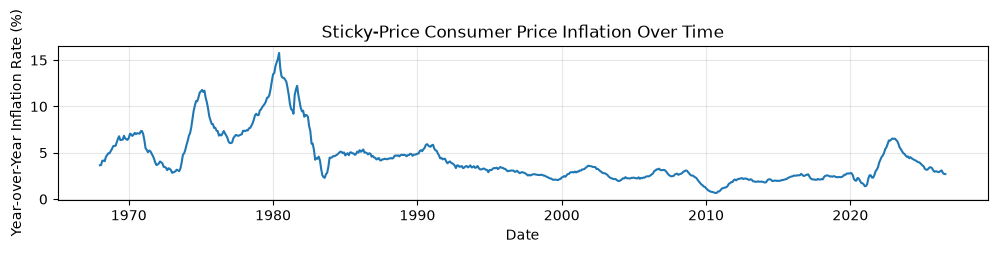

In [17]:
# lets view the whole dataset

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))

plt.plot(
    cpi_table["date"],
    cpi_table["value"]
)

plt.title("Sticky-Price Consumer Price Inflation Over Time")
plt.xlabel("Date")
plt.ylabel("Year-over-Year Inflation Rate (%)")
plt.grid(alpha=0.3)
plt.show()

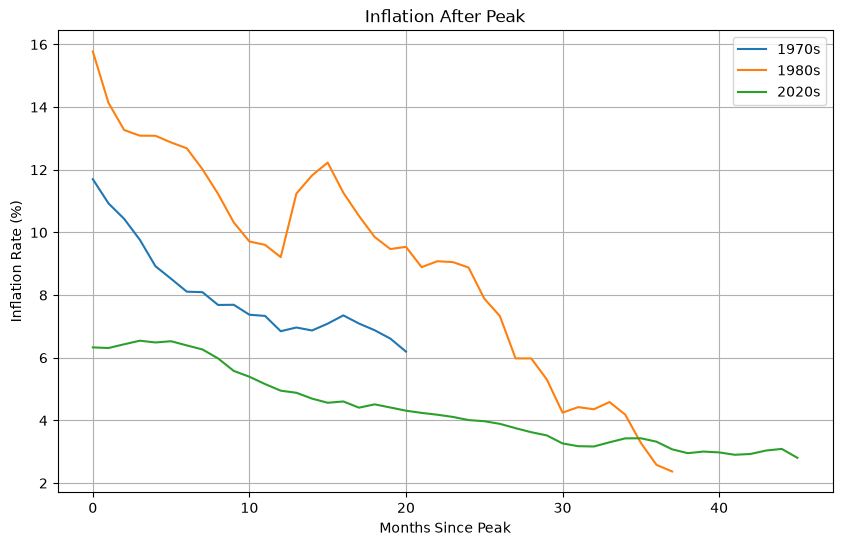

In [33]:


import matplotlib.pyplot as plt

 # I found out the peak and through dates for inflation in each of my target cycles, I let the latest cycle play out longer
target_ranges = {
    "1970s": ("1975-04-01", "1976-12-01"),
    "1980s": ("1980-06-01", "1983-07-01"),
    "2020s": ("2022-09-01", "2026-06-01")
}

plt.figure(figsize=(10, 6))

for name, (start, end) in target_ranges.items():

    # Get only data inside this range
    period = cpi_table[
        (cpi_table["date"] >= start) &
        (cpi_table["date"] <= end)
    ].copy()

    # Standardized x-axis to start from 0 instead of the datetime
    period["month"] = range(len(period))

    plt.plot(period["month"], period["value"], label=name)

plt.xlabel("Months Since Peak")
plt.ylabel("Inflation Rate (%)")
plt.title("Inflation After Peak")
plt.legend()
plt.grid(True)

plt.show()

    

- From this chart you can see inflation is the lowest it was in all three peaks 
- also that the cool-off is much more tame this time around, with around 33% cool off in 20 months vs 50% in the 70s and somewhere near 40% in the 80s 